In [ ]:
import torch
import torchvision
import os
import json
import math
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [ ]:
class DetectionTransform:
    def __init__(self, img_transforms):
        self.img_transforms = img_transforms

    def __call__(self, img, target):
        return self.img_transforms(img), target


class FasterRCNNDataset(Dataset):
    def __init__(self, img_dir, coco_path, transforms=None):
        self.img_dir = img_dir
        self.transforms = transforms

        with open(coco_path, "r") as f:
            coco = json.load(f)

        self.ann_map = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            self.ann_map.setdefault(img_id, []).append(ann)

        self.samples = []
        for img_info in coco["images"]:
            self.samples.append({
                "file_name": img_info["file_name"],
                "image_id": img_info["id"],
                "width": img_info["width"],
                "height": img_info["height"],
            })

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img_path = os.path.join(self.img_dir, sample["file_name"])
        img = Image.open(img_path).convert("RGB")

        anns = self.ann_map.get(sample["image_id"], [])

        if len(anns) == 0:
            next_idx = (idx + 1) % len(self)
            if next_idx == 0:
                raise RuntimeError(f"All images from index {idx} onward are empty")
            return self.__getitem__(next_idx)

        boxes = []
        labels = []
        areas = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])
            areas.append(ann["area"])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.zeros((len(anns),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([sample["image_id"]]),
            "area": areas,
            "iscrowd": iscrowd,
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.samples)

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
def get_transform():
    return DetectionTransform(T.Compose([T.ToTensor()]))

def get_ssd_transform():
    img_size = (300, 300)
    t = T.Compose([T.Resize(img_size), T.ToTensor()])
    def fn(img, target):
        orig_w, orig_h = img.size
        new_w, new_h = img_size
        img = t(img)
        boxes = target["boxes"].clone()
        boxes[:, 0::2] *= new_w / orig_w
        boxes[:, 1::2] *= new_h / orig_h
        target["boxes"] = boxes
        return img, target
    return fn

TRAIN_IMG = r"D:\cctv\stage\datasets\people.v1i.coco\train\images"
COCO_ANN = r"D:\cctv\stage\datasets\people.v1i.coco\train\labels\_annotations.coco.json"

train_dataset = FasterRCNNDataset(TRAIN_IMG, COCO_ANN, transforms=get_transform())

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10):
    model.train()
    header = f"Epoch: [{epoch}]"
    running_loss = 0.0

    for i, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        loss_value = losses.item()
        if not math.isfinite(loss_value):
            raise RuntimeError(f"Loss is {loss_value}, stopping training")

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += loss_value

        if (i + 1) % print_freq == 0:
            print(f"  step {i + 1}/{len(data_loader)}, loss: {loss_value:.4f}")

    avg_loss = running_loss / len(data_loader)
    print(f"{header} Average Loss: {avg_loss:.4f}")
    return avg_loss

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

num_epochs = 15
for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)
    torch.save(model.state_dict(), f"faster_rcnn_epoch_{epoch}.pth")

In [ ]:
import gc
import glob
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

if 'model' in globals():
    del model
    gc.collect()
    torch.cuda.empty_cache()
    print("Cleared existing model from GPU")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)

ckpt_files = sorted(glob.glob(r"D:\cctv\stage\notebooks\faster_rcnn_epoch_*.pth"))
if ckpt_files:
    last_ckpt = ckpt_files[-1]
    start_epoch = int(last_ckpt.split("_")[-1].split(".")[0]) + 1
    model.load_state_dict(torch.load(last_ckpt, weights_only=True, map_location=device))
    print(f"Resuming from {last_ckpt} (epoch {start_epoch})")
else:
    start_epoch = 0
    print("No checkpoints found, starting from scratch")

model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

total_epochs = 15
for epoch in range(start_epoch, total_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)
    torch.save(model.state_dict(), f"faster_rcnn_epoch_{epoch}.pth")


In [14]:
from torchvision.models.detection import ssd300_vgg16

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model_ssd = ssd300_vgg16(weights="DEFAULT")

num_classes = 2
ch = model_ssd.head.classification_head
new_convs = torch.nn.ModuleList()
for mod in ch.module_list:
    num_anchors = mod.out_channels // ch.num_columns
    new_convs.append(torch.nn.Conv2d(mod.in_channels, num_classes * num_anchors, kernel_size=3, padding=1))
ch.module_list = new_convs
ch.num_columns = num_classes

model_ssd.to(device)
optimizer_ssd = torch.optim.SGD(model_ssd.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)

ssd_dataset = FasterRCNNDataset(TRAIN_IMG, COCO_ANN, transforms=get_ssd_transform())
ssd_loader = DataLoader(ssd_dataset, batch_size=16, shuffle=True, num_workers=0, collate_fn=collate_fn)

for epoch in range(15):
    train_one_epoch(model_ssd, optimizer_ssd, ssd_loader, device, epoch)
    torch.save(model_ssd.state_dict(), f"ssd_epoch_{epoch}.pth")

  step 10/1352, loss: 83.2255
  step 20/1352, loss: 43.1808
  step 30/1352, loss: 41.6931
  step 40/1352, loss: 34.5678
  step 50/1352, loss: 70.0858
  step 60/1352, loss: 63.3882
  step 70/1352, loss: 55.4166
  step 80/1352, loss: 46.7438
  step 90/1352, loss: 54.3300
  step 100/1352, loss: 78.9457
  step 110/1352, loss: 55.7646
  step 120/1352, loss: 97.5822
  step 130/1352, loss: 40.0000
  step 140/1352, loss: 32.0596
  step 150/1352, loss: 63.1472
  step 160/1352, loss: 61.4427
  step 170/1352, loss: 50.7603
  step 180/1352, loss: 60.8984
  step 190/1352, loss: 33.6900
  step 200/1352, loss: 17.3197
  step 210/1352, loss: 64.3793
  step 220/1352, loss: 43.8632
  step 230/1352, loss: 44.9021
  step 240/1352, loss: 107.4332
  step 250/1352, loss: 39.4606
  step 260/1352, loss: 29.4413
  step 270/1352, loss: 127.4418
  step 280/1352, loss: 65.2631
  step 290/1352, loss: 32.1044
  step 300/1352, loss: 23.0155
  step 310/1352, loss: 67.7150
  step 320/1352, loss: 32.5378
  step 330/1352

RuntimeError: Loss is nan, stopping training

In [16]:
import gc
import glob
from torchvision.models.detection import ssd300_vgg16

if 'model_ssd' in globals():
    del model_ssd
    gc.collect()
    torch.cuda.empty_cache()
    print("Cleared existing SSD model from GPU")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model_ssd = ssd300_vgg16(weights="DEFAULT")
ch = model_ssd.head.classification_head
new_convs = torch.nn.ModuleList()
for mod in ch.module_list:
    num_anchors = mod.out_channels // ch.num_columns
    new_convs.append(torch.nn.Conv2d(mod.in_channels, 2 * num_anchors, kernel_size=3, padding=1))
ch.module_list = new_convs
ch.num_columns = 2

ckpt_files = sorted(glob.glob(r"D:\cctv\stage\notebooks\ssd_epoch_*.pth"))
if ckpt_files:
    last_ckpt = ckpt_files[-1]
    start_epoch = int(last_ckpt.split("_")[-1].split(".")[0]) + 1
    model_ssd.load_state_dict(torch.load(last_ckpt, weights_only=True, map_location=device))
    print(f"Resuming from {last_ckpt} (epoch {start_epoch})")
else:
    start_epoch = 0
    print("No SSD checkpoints found, starting from scratch")

model_ssd.to(device)
optimizer_ssd = torch.optim.SGD(model_ssd.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)

total_epochs = 15
for epoch in range(start_epoch, total_epochs):
    train_one_epoch(model_ssd, optimizer_ssd, ssd_loader, device, epoch)
    torch.save(model_ssd.state_dict(), f"ssd_epoch_{epoch}.pth")


Cleared existing SSD model from GPU
Resuming from D:\cctv\stage\notebooks\ssd_epoch_9.pth (epoch 10)
  step 10/1352, loss: 33.5170
  step 20/1352, loss: 18.5894
  step 30/1352, loss: 20.5924
  step 40/1352, loss: 32.3764
  step 50/1352, loss: 20.1202
  step 60/1352, loss: 12.7489
  step 70/1352, loss: 19.3569
  step 80/1352, loss: 13.0934
  step 90/1352, loss: 17.7197
  step 100/1352, loss: 11.5006
  step 110/1352, loss: 16.2068
  step 120/1352, loss: 11.3139
  step 130/1352, loss: 16.6855
  step 140/1352, loss: 28.2622
  step 150/1352, loss: 10.7769
  step 160/1352, loss: 12.3814
  step 170/1352, loss: 25.6855
  step 180/1352, loss: 15.8946
  step 190/1352, loss: 16.2655
  step 200/1352, loss: 13.1451
  step 210/1352, loss: 16.0656
  step 220/1352, loss: 7.9877
  step 230/1352, loss: 10.7067
  step 240/1352, loss: 18.2689
  step 250/1352, loss: 12.8807
  step 260/1352, loss: 14.5994
  step 270/1352, loss: 20.1178
  step 280/1352, loss: 16.8133
  step 290/1352, loss: 11.2815
  step 300

In [10]:
from ultralytics import YOLO
from IPython.display import display, Image

In [11]:
YOLO_VERSION = "yolo11s"
model = YOLO(YOLO_VERSION)
model.train(
    data=r"D:\cctv\stage\datasets\People.v1i.yolov8\data.yaml",
    epochs=15,
    imgsz=544,
    device=0,
    batch=16,
    name=f"train_{YOLO_VERSION}",
    save=True,
    plots=True,
    exist_ok=True,
)

New https://pypi.org/project/ultralytics/8.4.46 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.43  Python-3.12.5 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\cctv\stage\datasets\People.v1i.yolov8\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=544, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000027402F5EB70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

Evaluating Faster R-CNN...
  Loaded D:\cctv\stage\notebooks\faster_rcnn_epoch_14.pth
  Precision: 0.6271, Recall: 0.9341, Time: 52.9 ms
Evaluating SSD...
  Loaded D:\cctv\stage\notebooks\ssd_epoch_14.pth
  Precision: 0.3205, Recall: 0.1318, Time: 8.6 ms
Evaluating YOLO...
Ultralytics 8.4.43  Python-3.12.5 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 27.013.2 MB/s, size: 35.0 KB)
val: Scanning D:\cctv\stage\datasets\people.v1i.yolov8\valid\labels.cache... 1842 images, 417 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1842/1842  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 116/116 8.4it/s 13.8s0.1s
                   all       1842       3231      0.615      0.345      0.352      0.193
                person       1425       3231      0.615      0.345      0.352      0.193

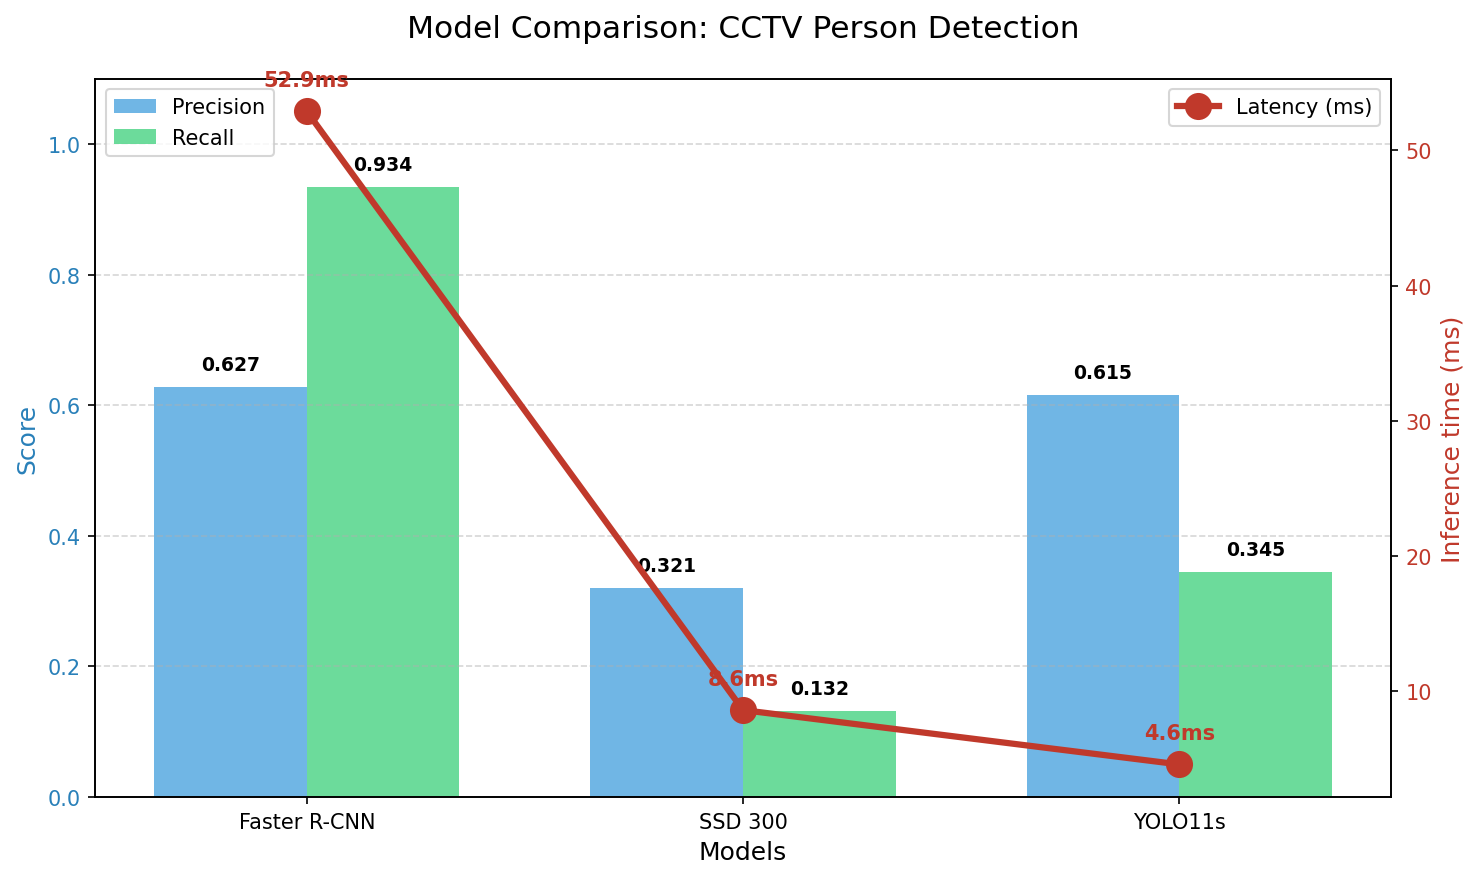

In [17]:
import time
import glob
import os
import json
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou
from ultralytics import YOLO
from IPython.display import display, Image as IPyImage

VAL_IMG = r"D:\cctv\stage\datasets\people.v1i.coco\train\images"
VAL_COCO = r"D:\cctv\stage\datasets\people.v1i.coco\train\labels\_annotations.coco.json"


class DetectionTransform:
    def __init__(self, img_transforms):
        self.img_transforms = img_transforms

    def __call__(self, img, target):
        return self.img_transforms(img), target


class EvalDataset(Dataset):
    def __init__(self, img_dir, coco_path, transforms=None, max_samples=None):
        self.img_dir = img_dir
        self.transforms = transforms
        with open(coco_path, "r") as f:
            coco = json.load(f)
        self.ann_map = {}
        for ann in coco["annotations"]:
            self.ann_map.setdefault(ann["image_id"], []).append(ann)
        self.samples = []
        for img_info in coco["images"]:
            self.samples.append({
                "file_name": img_info["file_name"],
                "image_id": img_info["id"],
                "width": img_info["width"],
                "height": img_info["height"],
            })
        if max_samples and max_samples < len(self.samples):
            self.samples = self.samples[:max_samples]

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img_path = os.path.join(self.img_dir, sample["file_name"])
        img = Image.open(img_path).convert("RGB")
        anns = self.ann_map.get(sample["image_id"], [])
        if len(anns) == 0:
            next_idx = (idx + 1) % len(self)
            if next_idx == 0:
                raise RuntimeError(f"All images from index {idx} onward are empty")
            return self.__getitem__(next_idx)
        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(1)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([sample["image_id"]])}
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.samples)


def collate_fn(batch):
    return tuple(zip(*batch))


def get_val_transform():
    return DetectionTransform(T.Compose([T.ToTensor()]))


def get_ssd_val_transform():
    img_size = (300, 300)
    t = T.Compose([T.Resize(img_size), T.ToTensor()])
    def fn(img, target):
        orig_w, orig_h = img.size
        new_w, new_h = img_size
        img = t(img)
        boxes = target["boxes"].clone()
        boxes[:, 0::2] *= new_w / orig_w
        boxes[:, 1::2] *= new_h / orig_h
        target["boxes"] = boxes
        return img, target
    return fn


def eval_tv_model(model, data_loader, device, num_samples=500, conf_thresh=0.5):
    model.eval()
    total_iou = 0.0
    total_tp = 0
    total_fp = 0
    total_fn = 0
    times = []
    seen = 0
    with torch.no_grad():
        for images, targets in data_loader:
            if seen >= num_samples:
                break
            images = list(img.to(device) for img in images)
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            preds = model(images)
            torch.cuda.synchronize()
            elapsed = (time.perf_counter() - t0) * 1000 / len(images)
            times.append(elapsed)
            for pred, tgt in zip(preds, targets):
                gt_boxes = tgt["boxes"].to(device)
                scores = pred["scores"]
                pred_boxes = pred["boxes"][scores > conf_thresh]
                if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                    continue
                if len(pred_boxes) == 0:
                    total_fn += len(gt_boxes)
                    continue
                if len(gt_boxes) == 0:
                    total_fp += len(pred_boxes)
                    continue
                iou_mat = box_iou(pred_boxes, gt_boxes)
                best_iou, best_gt = iou_mat.max(dim=1)
                matched_gt = set()
                tp = 0
                fp = 0
                for bi, (iou_v, gt_idx) in enumerate(zip(best_iou, best_gt)):
                    if iou_v >= 0.5 and gt_idx.item() not in matched_gt:
                        tp += 1
                        matched_gt.add(gt_idx.item())
                        total_iou += iou_v.item()
                    else:
                        fp += 1
                fn = len(gt_boxes) - len(matched_gt)
                total_tp += tp
                total_fp += fp
                total_fn += fn
                seen += 1
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    avg_time = sum(times) / len(times) if times else 0.0
    return precision, recall, avg_time


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
results = []

# --- Faster R-CNN ---
print("Evaluating Faster R-CNN...")
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
frcnn = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_f = frcnn.roi_heads.box_predictor.cls_score.in_features
frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_f, 2)
ckpt = sorted(glob.glob(r"D:\cctv\stage\notebooks\faster_rcnn_epoch_*.pth"), key=lambda x: int(x.split("_")[-1].split(".")[0]))
if ckpt:
    frcnn.load_state_dict(torch.load(ckpt[-1], weights_only=True, map_location=device))
    print(f"  Loaded {ckpt[-1]}")
frcnn.to(device)
val_ds = EvalDataset(VAL_IMG, VAL_COCO, transforms=get_val_transform(), max_samples=500)
val_ld = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)
p_frcnn, r_frcnn, t_frcnn = eval_tv_model(frcnn, val_ld, device)
results.append({"Model": "Faster R-CNN", "Precision": p_frcnn, "Recall": r_frcnn, "Inference_ms": t_frcnn})
print(f"  Precision: {p_frcnn:.4f}, Recall: {r_frcnn:.4f}, Time: {t_frcnn:.1f} ms")
del frcnn
torch.cuda.empty_cache()

# --- SSD ---
print("Evaluating SSD...")
from torchvision.models.detection import ssd300_vgg16
ssd = ssd300_vgg16(weights="DEFAULT")
ch = ssd.head.classification_head
new_convs = torch.nn.ModuleList()
for mod in ch.module_list:
    na = mod.out_channels // ch.num_columns
    new_convs.append(torch.nn.Conv2d(mod.in_channels, 2 * na, kernel_size=3, padding=1))
ch.module_list = new_convs
ch.num_columns = 2
ckpt_ssd = sorted(glob.glob(r"D:\cctv\stage\notebooks\ssd_epoch_*.pth"), key=lambda x: int(x.split("_")[-1].split(".")[0]))
if ckpt_ssd:
    ssd.load_state_dict(torch.load(ckpt_ssd[-1], weights_only=True, map_location=device))
    print(f"  Loaded {ckpt_ssd[-1]}")
ssd.to(device)
ssd_ds = EvalDataset(VAL_IMG, VAL_COCO, transforms=get_ssd_val_transform(), max_samples=500)
ssd_ld = DataLoader(ssd_ds, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)
p_ssd, r_ssd, t_ssd = eval_tv_model(ssd, ssd_ld, device)
results.append({"Model": "SSD 300", "Precision": p_ssd, "Recall": r_ssd, "Inference_ms": t_ssd})
print(f"  Precision: {p_ssd:.4f}, Recall: {r_ssd:.4f}, Time: {t_ssd:.1f} ms")
del ssd
torch.cuda.empty_cache()

# --- YOLO ---
print("Evaluating YOLO...")
yolo = YOLO("yolo11s")
ym = yolo.val(data=r"D:\cctv\stage\datasets\People.v1i.yolov8\data.yaml", imgsz=544, device=0)
map_yolo = ym.results_dict.get("metrics/mAP50(B)", 0)
t_yolo = ym.speed.get("inference", 0)
prec_yolo = ym.results_dict.get("metrics/precision(B)", 0)
rec_yolo = ym.results_dict.get("metrics/recall(B)", 0)
results.append({"Model": "YOLO11s", "Precision": prec_yolo, "Recall": rec_yolo, "Inference_ms": t_yolo})
print(f"  mAP@0.5: {map_yolo:.4f}, Precision: {prec_yolo:.4f}, Recall: {rec_yolo:.4f}, Time: {t_yolo:.1f} ms")

df = pd.DataFrame(results)
print("\n--- MODEL COMPARISON ---")
print(df.to_string(index=False))

models = df["Model"].tolist()
precisions = df["Precision"].tolist()
recalls = df["Recall"].tolist()
times_ms = df["Inference_ms"].tolist()
colors = ["#3498db", "#2ecc71", "#e74c3c"]

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(models))
w = 0.35
bars_p = ax1.bar([i - w/2 for i in x], precisions, w, color="#3498db", alpha=0.7, label="Precision")
bars_r = ax1.bar([i + w/2 for i in x], recalls, w, color="#2ecc71", alpha=0.7, label="Recall")
ax1.set_xlabel("Models", fontsize=12)
ax1.set_ylabel("Score", color="#2980b9", fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.set_xticks(list(x))
ax1.set_xticklabels(models)
ax1.tick_params(axis="y", labelcolor="#2980b9")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(models, times_ms, color="#c0392b", marker="o", linewidth=3, markersize=12, label="Latency (ms)")
ax2.set_ylabel("Inference time (ms)", color="#c0392b", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#c0392b")
ax2.legend(loc="upper right")

plt.title("Model Comparison: CCTV Person Detection", fontsize=15, pad=20)
ax1.grid(True, axis="y", linestyle="--", alpha=0.5)
for bar in bars_p:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., h + 0.02, f"{h:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=9)
for bar in bars_r:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., h + 0.02, f"{h:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=9)
for i, txt in enumerate(times_ms):
    ax2.annotate(f"{txt:.1f}ms", (models[i], times_ms[i]), textcoords="offset points", xytext=(0, 12), ha="center", color="#c0392b", fontweight="bold")
plt.tight_layout()
save_path = "model_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.close()
display(IPyImage(filename=save_path))
